# BÀI TẬP VỀ NHÀ - LSTM

## Bài 1: Dự báo chuỗi thời gian bằng LSTM (Sine Wave Forecasting)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 1. Tạo chuỗi 500 điểm (Sine wave + noise)
np.random.seed(42)
t = np.linspace(0, 100, 500)
data = np.sin(t) + 0.1 * np.random.randn(500)
data = data.reshape(-1, 1)

# Chuẩn hoá min-max
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data)

# 2. Tạo cửa sổ trượt (seq_length = 20)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 20
X, y = create_sequences(data_scaled, seq_length)

# Chia 70/15/15
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

# Chuyển sang Tensor
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

In [2]:
# 3. Build LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# 4. Training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 100
X_train, y_train = X_train.to(device), y_train.to(device)
X_val, y_val = X_val.to(device), y_val.to(device)

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        model.eval()
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

Epoch [20/100], Loss: 0.2530, Val Loss: 0.2346
Epoch [40/100], Loss: 0.1682, Val Loss: 0.1549
Epoch [60/100], Loss: 0.0085, Val Loss: 0.0094
Epoch [80/100], Loss: 0.0107, Val Loss: 0.0114
Epoch [100/100], Loss: 0.0078, Val Loss: 0.0089


Test MSE: 0.0095


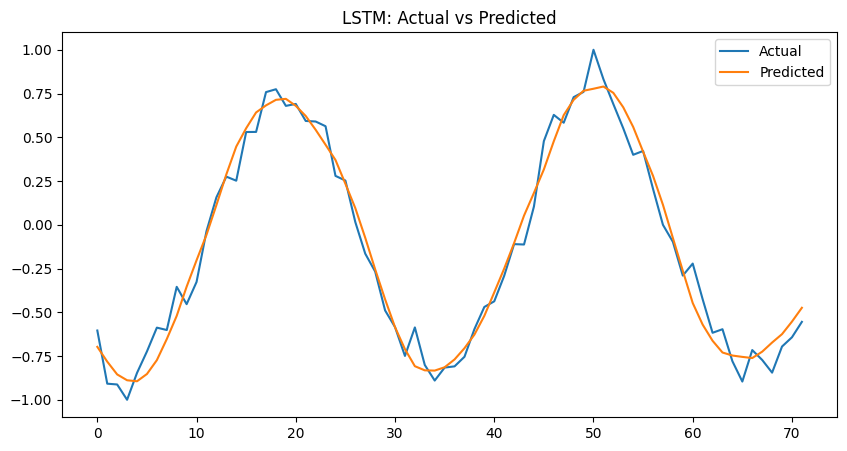

In [3]:
# 5. Đánh giá trên test
model.eval()
X_test, y_test = X_test.to(device), y_test.to(device)
with torch.no_grad():
    test_predict = model(X_test)
    test_loss = criterion(test_predict, y_test)
    print(f'Test MSE: {test_loss.item():.4f}')

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(y_test.cpu().numpy(), label='Actual')
plt.plot(test_predict.cpu().numpy(), label='Predicted')
plt.legend()
plt.title('LSTM: Actual vs Predicted')
plt.show()

## Bài 2: Phân loại sentiment trên dữ liệu thật (Demo logic với sample dữ liệu)

In [4]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

# Giả lập dataset sentiment
sentences = [
    "Sản phẩm tuyệt vời", "Rất hài lòng về chất lượng", "Giao hàng nhanh",
    "Tệ quá", "Chất lượng kém", "Không đáng tiền", "Sẽ mua lại",
    "Thất vọng", "Dùng rất tốt", "Hàng hỏng khi nhận"
]
labels = [1, 1, 1, 0, 0, 0, 1, 0, 1, 0]

# 1. Tiền xử lý đơn giản
vocab = {"<pad>": 0, "<unk>": 1}
for sent in sentences:
    for word in sent.lower().split():
        if word not in vocab:
            vocab[word] = len(vocab)

def encode(sent):
    return [vocab.get(word, 1) for word in sent.lower().split()]

encoded_sentences = [torch.tensor(encode(s)) for s in sentences]
lengths = torch.tensor([len(s) for s in encoded_sentences])
X_padded = pad_sequence(encoded_sentences, batch_first=True, padding_value=0)
y_tensor = torch.tensor(labels)

# 2. Build Bi-LSTM
class SentimentBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, lens):
        embedded = self.dropout(self.embedding(x))
        packed = pack_padded_sequence(embedded, lens.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        # Concatenate hidden state của 2 chiều
        h_concat = torch.cat((h_n[-2,:,:], h_n[-1,:,:]), dim=1)
        return self.fc(h_concat)

model_sent = SentimentBiLSTM(len(vocab), 16, 32).to(device)
optimizer_sent = optim.Adam(model_sent.parameters(), lr=0.01)
criterion_sent = nn.CrossEntropyLoss()

# Train demo
for epoch in range(50):
    model_sent.train()
    optimizer_sent.zero_grad()
    logits = model_sent(X_padded.to(device), lengths)
    loss = criterion_sent(logits, y_tensor.to(device))
    loss.backward()
    optimizer_sent.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

Epoch 10, Loss: 0.1124
Epoch 20, Loss: 0.0014
Epoch 30, Loss: 0.0004
Epoch 40, Loss: 0.0001
Epoch 50, Loss: 0.0000


## Bài 3: Sinh văn bản (Character-level Language Model)

In [5]:
text = "Trăm năm trong cõi người ta, chữ tài chữ mệnh khéo là ghét nhau. Trải qua một cuộc bể dâu, những điều trông thấy mà đau đớn lòng."
chars = sorted(list(set(text)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

seq_len = 20
inputs, targets = [], []
for i in range(len(text) - seq_len):
    inputs.append([char_to_idx[ch] for ch in text[i:i+seq_len]])
    targets.append(char_to_idx[text[i+seq_len]])

X_gen = torch.tensor(inputs, dtype=torch.long)
y_gen = torch.tensor(targets, dtype=torch.long)

class TextGenLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        e = self.embedding(x)
        out, _ = self.lstm(e)
        return self.fc(out[:, -1, :])

model_gen = TextGenLSTM(len(chars), 32, 128).to(device)
optimizer_gen = optim.Adam(model_gen.parameters(), lr=0.005)

for epoch in range(100):
    model_gen.train()
    optimizer_gen.zero_grad()
    outputs = model_gen(X_gen.to(device))
    loss = nn.CrossEntropyLoss()(outputs, y_gen.to(device))
    loss.backward()
    optimizer_gen.step()

# Sinh văn bản
seed = "Trăm năm trong cõi "
generated = seed
model_gen.eval()
with torch.no_grad():
    for _ in range(50):
        x = torch.tensor([[char_to_idx[ch] for ch in generated[-seq_len:]]]).to(device)
        pred = model_gen(x)
        idx = torch.argmax(pred, dim=1).item()
        generated += idx_to_char[idx]
print("Generated text:", generated)

Generated text: Trăm năm trong cõi gười ta, chữ tài chữ mệnh khéo là ghét nhau. Trải 
